# Brazilian E-Commerce (Olist) — Exploratory Data Analysis

**Dataset:** Brazilian E-Commerce Public Dataset by Olist — ~100K orders, 2016–2018, 9 CSV files  
**Goal:** Full EDA to identify growth patterns, retention issues, delivery bottlenecks, and actionable business recommendations  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  


## 1. Import & Data Preparation

In [464]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [465]:
orders = pd.read_csv('olist_orders_dataset.csv')

In [466]:
items = pd.read_csv('olist_order_items_dataset.csv')

In [467]:
payments = pd.read_csv('olist_order_payments_dataset.csv')

In [468]:
reviews = pd.read_csv('olist_order_reviews_dataset.csv')

In [469]:
customers = pd.read_csv('olist_customers_dataset.csv')

In [470]:
sellers = pd.read_csv('olist_sellers_dataset.csv')

In [471]:
products = pd.read_csv('olist_products_dataset.csv')

In [472]:
geolocation = pd.read_csv('olist_geolocation_dataset.csv')

In [473]:
categories = pd.read_csv('product_category_name_translation.csv')

In [474]:
tables = {
    'orders': orders, 'items': items, 'payments': payments,
    'reviews': reviews, 'customers': customers, 'sellers': sellers,
    'products': products, 'geolocation': geolocation, 'categories': categories
}

In [475]:
for name, table in tables.items():
    print(f"{name}: {table.shape}")

orders: (99441, 8)
items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 7)
customers: (99441, 5)
sellers: (3095, 4)
products: (32951, 9)
geolocation: (1000163, 5)
categories: (71, 2)


In [476]:
orders.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [477]:
orders['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [478]:
products.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [479]:
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']

In [480]:
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

### Merge

In [481]:
df_raw = orders.merge(items, how='left', on='order_id')

In [482]:
df_raw = df_raw.merge(payments, how='left', on='order_id')

In [483]:
df_raw = df_raw.merge(customers, how='left', on='customer_id')

In [484]:
df_raw = df_raw.merge(products, how='left', on='product_id')

In [485]:
df_raw = df_raw.merge(categories, how='left', on='product_category_name')

In [486]:
df_raw.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,BA,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,GO,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto


In [487]:
df_raw.shape

(118434, 31)

In [488]:
# Замовлення без товарів — unavailable/canceled
df_raw[df_raw['product_id'].isna()]['order_status'].value_counts()

,count
order_status,
unavailable,643
canceled,179
created,5
invoiced,2
shipped,1


### Cleaning

Видалення порожніх замовлень (товари відсутні, скасовані без товарів) — менше 1 % даних.

In [489]:
df = df_raw.copy()

In [490]:
df = df[df['product_id'].notna()]

In [491]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,BA,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,GO,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto


In [492]:
df['product_category_name_english'] = df['product_category_name_english'].fillna('Unknown')

In [493]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

In [494]:
df['revenue'] = df['price'] + df['freight_value']

In [495]:
df.shape

(117604, 33)

## 2. Big Picture

In [496]:
print(f"Unique orders: {df['order_id'].nunique():,}")
print(f"Unique customers: {df['customer_unique_id'].nunique():,}")
print(f"Unique sellers: {df['seller_id'].nunique():,}")
print(f"Product categories: {df['product_category_name'].nunique()}")
print(f"Period: {df['order_purchase_timestamp'].min().date()} to {df['order_purchase_timestamp'].max().date()}")
print(f"Total revenue: ${df['revenue'].sum():,.2f}")

Unique orders: 98,666
Unique customers: 95,420
Unique sellers: 3,095
Product categories: 73
Period: 2016-09-04 to 2018-09-03
Total revenue: $16,566,687.31


In [497]:
month_trend = df.groupby('order_month').agg(
    month_revenue=('revenue', 'sum'),
    month_orders=('order_id', 'nunique')
).reset_index()

In [498]:
month_trend['aov'] = (month_trend['month_revenue'] / month_trend['month_orders']).round()

In [499]:
month_trend

,order_month,month_revenue,month_orders,aov
0,2016-09,354.75,3,118.0
1,2016-10,58550.03,308,190.0
2,2016-12,19.62,1,20.0
3,2017-01,146455.54,789,186.0
4,2017-02,302230.37,1733,174.0
5,2017-03,457782.29,2641,173.0
6,2017-04,448742.78,2391,188.0
7,2017-05,630089.88,3660,172.0
8,2017-06,526495.91,3217,164.0
9,2017-07,627312.81,3969,158.0


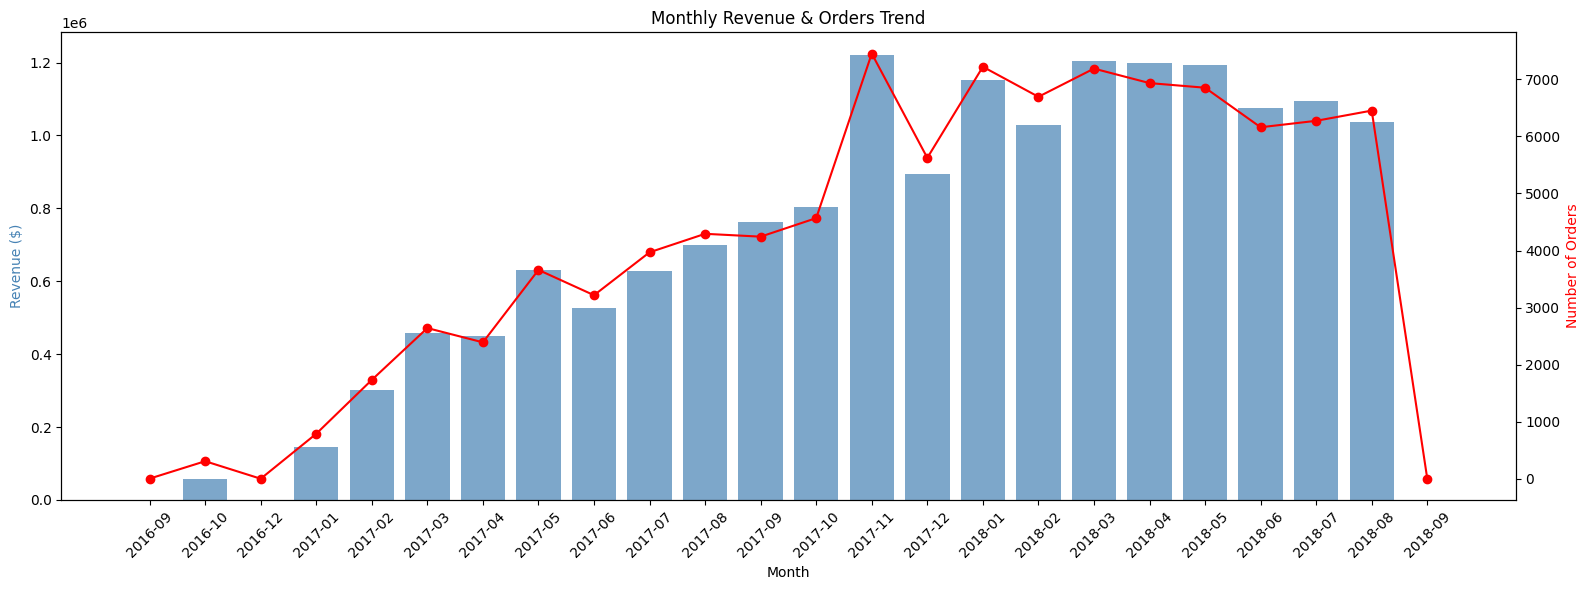

In [500]:
fig, ax1 = plt.subplots(figsize=(16, 6))

ax1.bar(month_trend['order_month'].astype(str), month_trend['month_revenue'],
        color='steelblue', alpha=0.7, label='Revenue')
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue ($)', color='steelblue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(month_trend['order_month'].astype(str), month_trend['month_orders'],
         color='red', marker='o', label='Orders')
ax2.set_ylabel('Number of Orders', color='red')

plt.title('Monthly Revenue & Orders Trend')
fig.tight_layout()
plt.show()

**Findings:**

Маркетплейс Olist за 2 роки обробив 98,666 замовлень від 95,420 унікальних клієнтів через 3,095 продавців у 73 категоріях товарів. Загальний revenue — $16.57M.

Співвідношення замовлень до клієнтів майже 1:1 — перший сигнал що повторні покупки практично відсутні.

Revenue зріс у 8 разів за 2017 рік (з $146K до $1.2M/міс), але у 2018 вийшов на плато $1.0–1.2M/міс — класичний growth plateau. Зростання відбувалось виключно за рахунок нових клієнтів: AOV залишався стабільним на рівні $160–180, тобто додаткові продажі та перехресні продажі не працювали.

Сезонні патерни: листопад 2017 — найсильніший місяць ($1.2M), що пояснюється Black Friday. При цьому AOV у листопаді падає до $164 — клієнти купують більше, але дешевші товари по акціях. Червень 2017 — просідання на 16.4% MoM, що пояснюється початком сезону відпусток.

*Примітка: перші місяці (2016-09, 2016-10, 2016-12) та останній (2018-09) мають неповні дані і виключені з аналізу трендів.*

## 3. Customer Analysis

### 3.1 New vs Returning Customers

In [501]:
customer_unique_count = df['customer_unique_id'].nunique()

In [502]:
customers_orders = df.groupby('customer_unique_id')['order_id'].nunique()

In [503]:
unique_users_count = (customers_orders > 1).sum()

In [504]:
pct_orders = ((unique_users_count / customer_unique_count) * 100).round(1)

In [505]:
print(f'Total unique customers: {customer_unique_count:,}')
print(f'Customers with repeat purchases: {unique_users_count:,} ({pct_orders}%)')

Total unique customers: 95,420
Customers with repeat purchases: 2,913 (3.1%)


З 95,420 унікальних клієнтів лише 2,913 (3.1%) зробили більше одного замовлення. 97% клієнтів купують один раз і не повертаються.

Це означає що весь revenue-growth тримається на придбання — залучення нових клієнтів. Це дорожча і менш стійка модель зростання ніж retention, особливо коли ринок нових клієнтів почне насичуватись (що вже видно у growth plateau 2018).

Рекомендація: запустити NPS-опитування у двох сегментах — повторні клієнти (що мотивує повертатись?) і одноразові (які бар'єри для повторної покупки?). Це дасть фундамент для побудови retention-стратегії.

*Limitation: один клієнт може мати різні customer_unique_id (інший email/акаунт), тому реальний repeat rate може бути дещо вищим.*

### 3.2 Customer Distribution by State

In [506]:
state_data = df.groupby('customer_state').agg(
    cnt_customers=('customer_unique_id', 'nunique'),
    revenue=('revenue', 'sum'),
).sort_values(['cnt_customers', 'revenue'], ascending=[False, False]).reset_index()

In [507]:
state_data['part_revenue'] = (state_data['revenue'] / state_data['revenue'].sum() * 100).round(2)

In [508]:
# AOV Середня вартість замовлення за штатом — спочатку потрібно отримати дохід за замовленнями, а потім розрахувати середній показник за штатом
order_revenue = df.groupby(['customer_state', 'order_id'])['revenue'].sum().reset_index()

In [509]:
aov_by_state = order_revenue.groupby('customer_state')['revenue'].mean().reset_index()

In [510]:
aov_by_state.columns = ['customer_state', 'aov']

In [511]:
state_data = state_data.merge(aov_by_state, on='customer_state')

In [512]:
state_data.head()

,customer_state,cnt_customers,revenue,part_revenue,aov
0,SP,39981,6201661.39,37.43,149.889097
1,RJ,12303,2236978.11,13.50,175.284290
2,MG,11178,1920938.14,11.60,166.401433
3,RS,5249,929350.22,5.61,171.088038
4,PR,4840,828526.16,5.00,165.771541


In [513]:
state_data.tail()

,customer_state,cnt_customers,revenue,part_revenue,aov
22,RO,235,58681.50,0.35,237.576923
23,AM,142,28465.90,0.17,193.645578
24,AC,77,20861.50,0.13,257.549383
25,AP,67,16517.39,0.10,242.902794
26,RR,45,10064.62,0.06,218.796087


In [514]:
top_5_part = (state_data['revenue'].head(5).sum() / state_data['revenue'].sum() * 100).round(2)


In [515]:
print(f'Top-5 states share of total revenue: {top_5_part}%')

Top-5 states share of total revenue: 73.14%


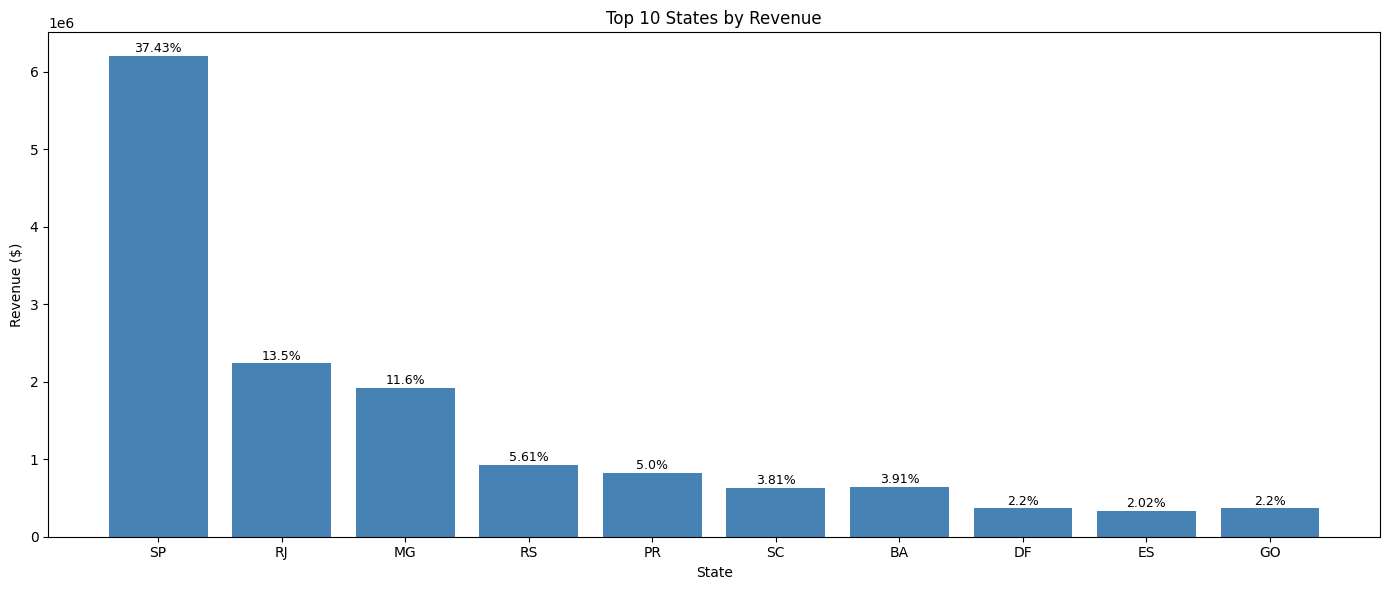

In [516]:
fig, ax = plt.subplots(figsize=(14, 6))
top10_states = state_data.head(10)
ax.bar(top10_states['customer_state'], top10_states['revenue'], color='steelblue')
ax.set_title('Top 10 States by Revenue')
ax.set_xlabel('State')
ax.set_ylabel('Revenue ($)')

for i, row in top10_states.iterrows():
    ax.text(i, row['revenue'] + 50000, f"{row['part_revenue']}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Топ-5 штатів генерують 73.1% revenue: São Paulo (37.4%), Rio de Janeiro (13.5%), Minas Gerais (11.6%), Rio Grande do Sul (5.6%), Paraná (5.0%). São Paulo один відповідає за більш ніж третину всього бізнесу — це одночасно і сила (великий ринок), і вразливість (залежність від одного регіону).

Цікавий парадокс: AOV у найменших штатах (Acre — $258, Amapá — $243, Roraima — $238) значно  вищий  ніж  у великих (São Paulo — $150). Причина — висока вартість доставки у віддалені регіони, яка входить у revenue (price + freight). Це не означає що клієнти там купують дорожче — вони платять більше за логістику.

*Limitation: штати з малою вибіркою (45–235 клієнтів) дають нестабільні середні показники.*

### 3.3 Cohort Retention Analysis

In [517]:
first_buy = df.groupby('customer_unique_id')['order_purchase_timestamp'].min().dt.to_period('M').reset_index()

In [518]:
first_buy.columns = ['customer_unique_id', 'cohort_month']

In [519]:
df = df.merge(first_buy, how='left', on='customer_unique_id')

In [520]:
df['cohort_index'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n)

In [521]:
cohort_table = df.pivot_table(
    values='customer_unique_id',
    index='cohort_month',
    columns='cohort_index',
    aggfunc='nunique'
)

In [522]:
retention = (cohort_table.div(cohort_table[0], axis=0) * 100).round(2)

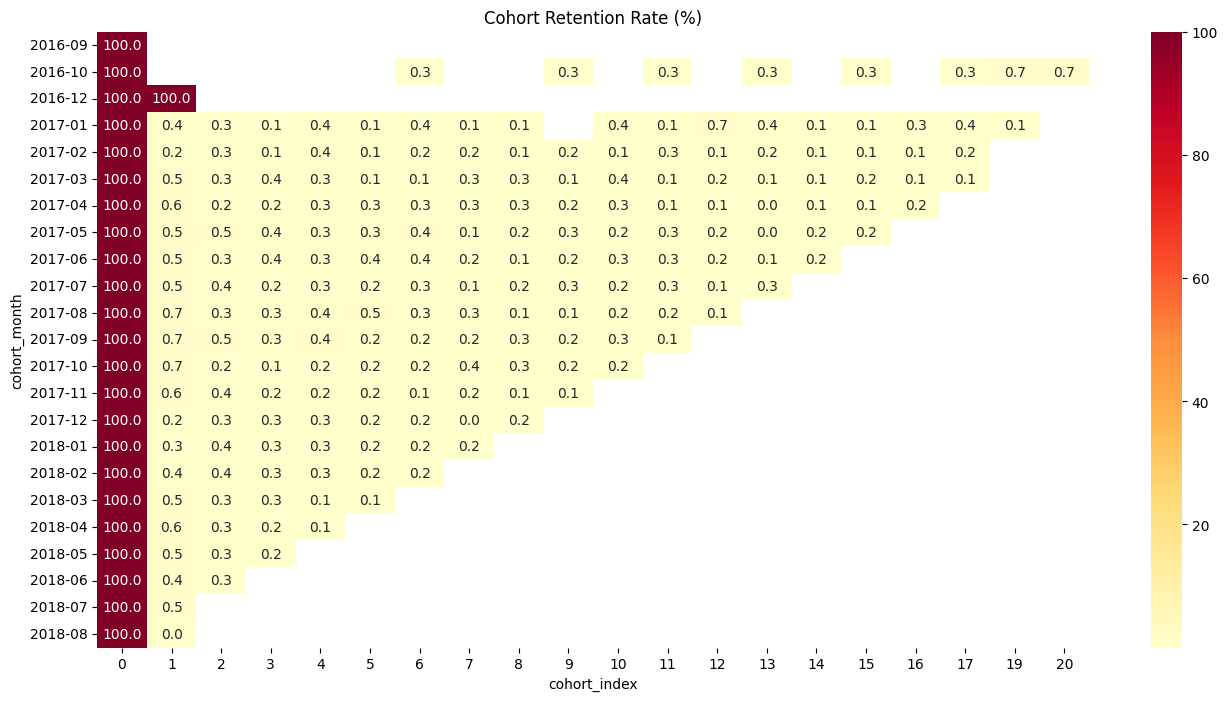

In [523]:
plt.figure(figsize=(16, 8))
sns.heatmap(retention, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Cohort Retention Rate (%)')
plt.show()

Когортний аналіз підтверджує критичний стан retention. Жодна когорта не утримує навіть 1% клієнтів після першого місяця. Типовий показник: когорта з 5,000+ клієнтів втрачає 99.5% вже на другий місяць.

Покращення між когортами відсутнє — когорти 2018 року утримують клієнтів не краще ніж когорти 2017. За рік роботи платформа не зробила прогресу у retention, що підтверджує відсутність системної retention-стратегії.

Для маркетплейсу низький retention частково нормальний (клієнт купив конкретний товар і не має потреби повертатись), але показники нижче 1% сигналізують про повну відсутність механізмів повторного залучення: email-нагадувань, програми лояльності, персоналізованих рекомендацій.

*Limitation: когорти з малою вибіркою (2016-09: 3 клієнти, 2016-12: 1 клієнт) виключені з інтерпретації через нерепрезентативність.*

## 4. Product Analysis

In [524]:
category_info = df.groupby('product_category_name_english').agg(
    cat_revenue=('revenue', 'sum'),
    cat_orders=('order_id', 'nunique')
).sort_values(['cat_revenue', 'cat_orders'], ascending=[False, False]).reset_index()

In [525]:
cat_rev = df.groupby(['product_category_name_english', 'order_id'])['revenue'].sum().reset_index()

In [526]:
aov_cat_rev = cat_rev.groupby('product_category_name_english')['revenue'].mean().reset_index()

In [527]:
aov_cat_rev.columns = ['product_category_name_english', 'aov']

In [528]:
category_info = category_info.merge(aov_cat_rev, how='left', on='product_category_name_english')

In [529]:
category_info.head(10)

,product_category_name_english,cat_revenue,cat_orders,aov
0,health_beauty,1486023.75,8836,168.178333
1,watches_gifts,1357478.82,5624,241.372479
2,bed_bath_table,1310284.13,9417,139.140292
3,sports_leisure,1198524.35,7720,155.249268
4,computers_accessories,1095456.98,6689,163.769918
5,furniture_decor,946593.12,6449,146.781380
6,housewares,820851.24,5884,139.505649
7,cool_stuff,750150.02,3632,206.539102
8,auto,712442.08,3897,182.818086
9,garden_tools,623851.98,3518,177.331433


In [530]:
category_info.tail(10)

,product_category_name_english,cat_revenue,cat_orders,aov
62,fashio_female_clothing,3425.39,39,87.830513
63,fashion_sport,2697.64,27,99.912593
64,la_cuisine,2690.87,13,206.990000
65,arts_and_craftmanship,2184.14,23,94.962609
66,diapers_and_hygiene,2141.27,27,79.306296
67,flowers,1598.91,29,55.134828
68,home_comfort_2,1194.44,24,49.768333
69,cds_dvds_musicals,954.99,12,79.582500
70,fashion_childrens_clothes,665.36,8,83.170000
71,security_and_services,324.51,2,162.255000


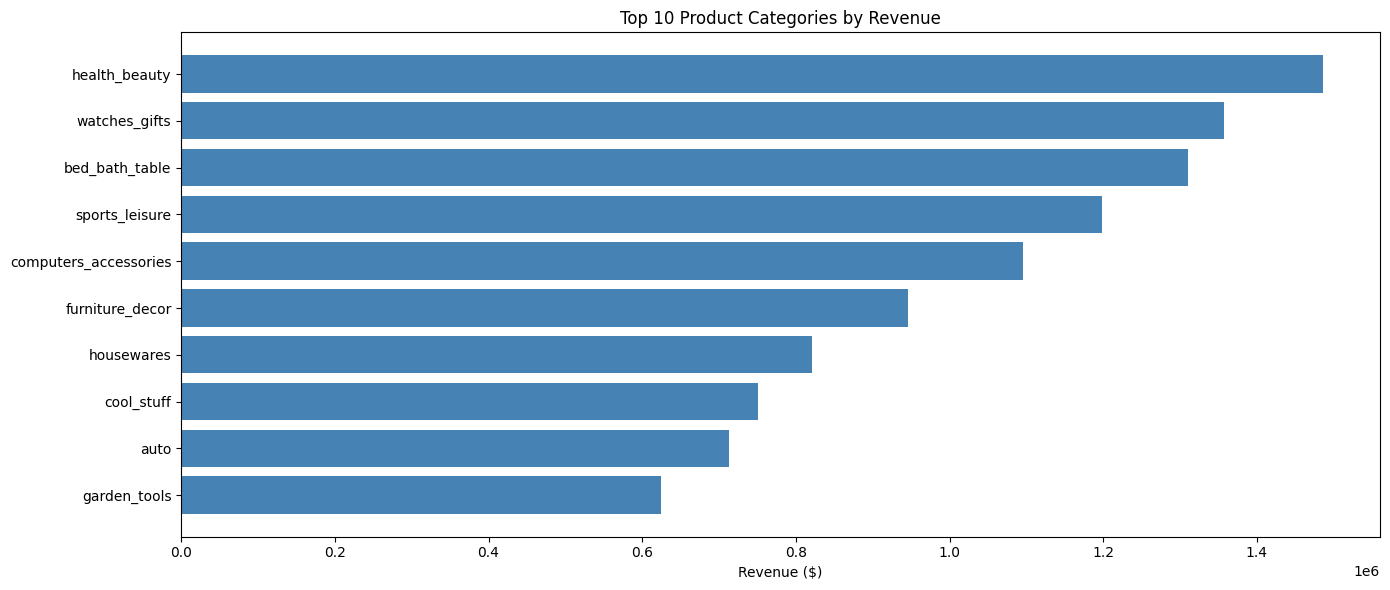

In [531]:
top10_cats = category_info.head(10)

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(top10_cats['product_category_name_english'][::-1], top10_cats['cat_revenue'][::-1], color='steelblue')
ax.set_title('Top 10 Product Categories by Revenue')
ax.set_xlabel('Revenue ($)')
plt.tight_layout()
plt.show()

In [532]:
top5_cats = category_info.head(5)['product_category_name_english'].tolist()

In [533]:
df_top5 = df[df['product_category_name_english'].isin(top5_cats)]

In [534]:
trend_top_cat = df_top5.groupby(['order_month', 'product_category_name_english'])['revenue'].sum().reset_index()

In [535]:
trend_top_cat_pivot = trend_top_cat.pivot_table(
    values='revenue',
    index='order_month',
    columns='product_category_name_english'
)

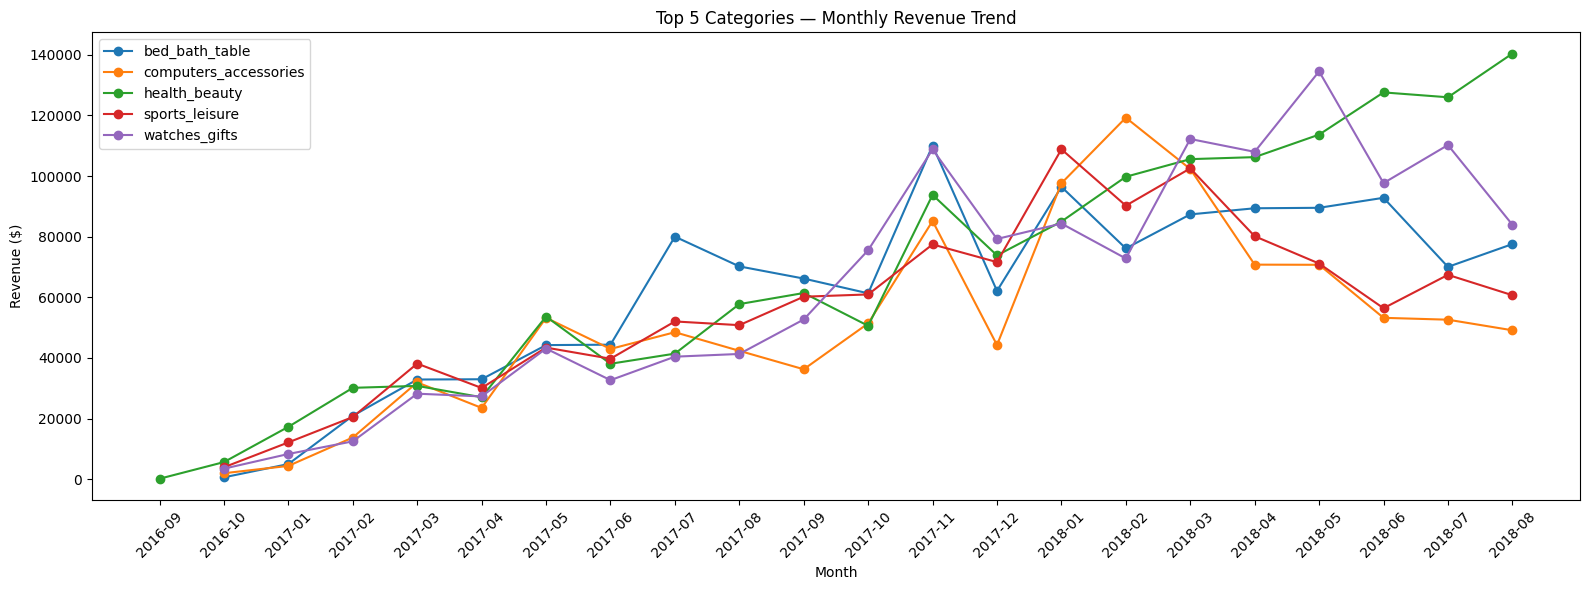

In [536]:
plt.figure(figsize=(16, 6))
for col in trend_top_cat_pivot.columns:
    plt.plot(trend_top_cat_pivot.index.astype(str), trend_top_cat_pivot[col], marker='o', label=col)

plt.title('Top 5 Categories — Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Health_beauty лідирує по revenue ($1.49M), але не по кількості замовлень — лідер  тут  bed_bath_table  (9,417 замовлень). Це різні бізнес-моделі: health_beauty продає менше одиниць з вищим AOV ($168), bed_bath_table — масовий недорогий товар (AOV $139).

Watches_gifts має найвищий AOV серед топ-10 ($241) — категорія дорогих подарунків з вираженою сезонністю (пік $108K у листопаді 2017 — святковий сезон). Cool_stuff ($207 AOV) показує схожий патерн — дорожчі товари, менший обсяг.

У хвості рейтингу — fashion_female_clothing (39 замовлень), що нетипово для e-commerce де ця категорія зазвичай у топі. Це сигнал для перегляду асортименту або каналів залучення. La_cuisine — нішева категорія з високим AOV ($207) при 13 замовленнях. Security_and_services — 2 замовлення, послуги мають мінімальний попит на маркетплейсі.

Тренд топ-5 категорій показує що health_beauty стабільно зростає і стає безумовним лідером у 2018 (з $17K у січні 2017 до $140K у серпні 2018). Листопад 2017 — пік для всіх 5 категорій, що підтверджує загальний Black Friday ефект.

## 5. Delivery Analysis

In [537]:
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

In [538]:
print(f"Average delivery time: {df['delivery_days'].mean():.1f} days")

Average delivery time: 12.0 days


In [539]:
late_delivery = df[df['order_delivered_customer_date'] > df['order_estimated_delivery_date']]

In [540]:
late_count = late_delivery['order_id'].nunique()

In [541]:
late_count

7827

In [542]:
pct_late_delivery = round(late_count / df['order_id'].nunique() * 100, 2)

In [543]:
print(f'Late deliveries: {late_count:,} orders ({pct_late_delivery}%)')

Late deliveries: 7,827 orders (7.93%)


In [544]:
state_delivery = df.groupby('customer_state')['delivery_days'].mean().sort_values(ascending=False).reset_index()

In [545]:
state_delivery

,customer_state,delivery_days
0,RR,27.826087
1,AP,27.662651
2,AM,26.100592
3,AL,24.138322
4,PA,23.255963
5,MA,21.255501
6,SE,20.886010
7,CE,20.354903
8,AC,20.170213
9,PB,20.126806


Середній термін доставки — 12 днів. 7.9% замовлень (7,827) доставлені із запізненням — кожне 12-те замовлення приходить пізніше обіцяного терміну.

Географія визначає швидкість: São Paulo — 8 днів (логістичний хаб країни), Roraima — 28 днів (віддалений північний штат). Різниця у 3.4 рази. Це пояснює і парадокс AOV з Customer Analysis: високий AOV у віддалених штатах — це не дорожчі товари, а дорожча доставка.

Зв'язок доставки з задоволеністю клієнтів перевіримо у наступному розділі (Review Analysis).

## 6. Review Analysis

In [546]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,order_month,revenue,cohort_month,cohort_index,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,500.0,19.0,8.0,13.0,housewares,2017-10,38.71,2017-09,1,8.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,500.0,19.0,8.0,13.0,housewares,2017-10,38.71,2017-09,1,8.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,500.0,19.0,8.0,13.0,housewares,2017-10,38.71,2017-09,1,8.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,400.0,19.0,13.0,19.0,perfumery,2018-07,141.46,2018-07,0,13.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,420.0,24.0,19.0,21.0,auto,2018-08,179.12,2018-08,0,9.0


In [547]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'order_month', 'revenue',
       'cohort_month', 'cohort_index', 'delivery_days'],
      dtype='object')

In [548]:
reviews_dedup = reviews.sort_values('review_creation_date').drop_duplicates('order_id', keep='last')


In [549]:
df = df.merge(reviews_dedup[['order_id', 'review_score']], on='order_id', how='left')

In [550]:
df.shape

(117604, 37)

In [551]:
assessment_rate = df.groupby('review_score').agg(
    cnt_orders=('order_id', 'nunique'),
    avg_delivery_time=('delivery_days', 'mean')
).reset_index().round(2)

In [552]:
assessment_rate

,review_score,cnt_orders,avg_delivery_time
0,1.0,10826,19.14
1,2.0,3068,15.36
2,3.0,8081,13.55
3,4.0,19011,11.77
4,5.0,56931,10.19


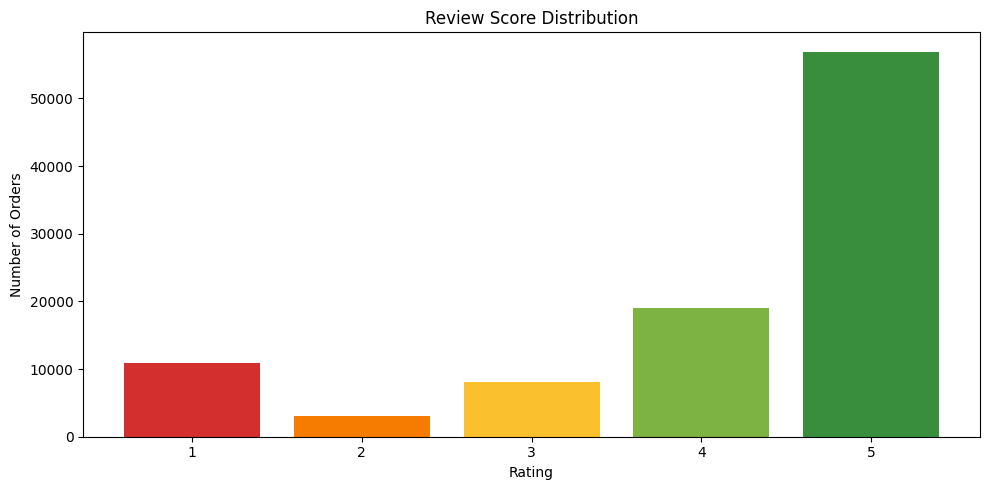

In [553]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d32f2f', '#f57c00', '#fbc02d', '#7cb342', '#388e3c']
ax.bar(assessment_rate['review_score'].astype(int).astype(str), assessment_rate['cnt_orders'], color=colors)
ax.set_title('Review Score Distribution')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Orders')
plt.tight_layout()
plt.show()

In [554]:
bad_orders = df.drop_duplicates('order_id')

In [555]:
bad_rate = round((bad_orders['review_score'] < 3).sum() / bad_orders['review_score'].count() * 100, 2)

In [556]:
print(f'Orders with low rating (< 3): {bad_rate}%')

Orders with low rating (< 3): 14.19%


In [557]:
df['is_late'] = df['order_delivered_customer_date'] > df['order_estimated_delivery_date']

In [558]:
late_assessment = df.groupby('is_late')['review_score'].mean().reset_index()
late_assessment

,is_late,review_score
0,False,4.153334
1,True,2.545341


58% замовлень отримують 5 зірок, але 16.1% мають оцінку нижче 3 — кожне 6-те замовлення залишає негативне враження.

Залежність між доставкою і оцінкою — пряма і сильна: замовлення з 5 зірками мають середній час доставки 10 днів, з 1 зіркою — 19 днів. Запізнення доставки є ключовим фактором незадоволеності: середня оцінка вчасних замовлень — 4.15, запізнілих — 2.55 (падіння на 1.6 бали).

Це замикає ланцюг: віддалені штати → довга доставка → низькі оцінки → низький repeat rate. Покращення логістики у проблемних регіонах матиме каскадний ефект на задоволеність і retention.

## 7. Payment Analysis

In [559]:
payment_allocation = df.groupby('payment_type').agg(
    cnt_orders=('order_id', 'nunique'),
    part_of_revenue=('revenue', 'sum'),
    avg_installments=('payment_installments', 'mean')
).reset_index()

In [560]:
payment_allocation['pct_revenue'] = (payment_allocation['part_of_revenue'] / payment_allocation['part_of_revenue'].sum() * 100).round(1)

In [561]:
payment_allocation

,payment_type,cnt_orders,part_of_revenue,avg_installments,pct_revenue
0,boleto,19614,2842240.29,1.000000,17.2
1,credit_card,75991,12723914.88,3.628646,76.8
2,debit_card,1521,215306.74,1.000000,1.3
3,voucher,3766,785081.94,1.000000,4.7


Кредитна карта — домінуючий спосіб оплати: 76.8% revenue (75,991 замовлення). Boleto (бразильський банківський переказ) — другий з 17.2%. Debit card (1.3%) і voucher (4.7%) мають мінімальну частку.

Середня розстрочка по кредитних картках — 3.6 платежі. Boleto, debit та voucher завжди оплачуються одним платежем. Розстрочка (parcelamento) — стандартна практика бразильського e-commerce, і її підтримка є обов'язковою умовою для маркетплейсу.

## 8. Seller Analysis (Pareto)

In [562]:
seller_revenue = df.groupby('seller_id')['revenue'].sum().sort_values(ascending=False).reset_index()

In [563]:
seller_revenue['pct_revenue'] = seller_revenue['revenue'] / seller_revenue['revenue'].sum() * 100

In [564]:
seller_revenue['cumulative_pct'] = seller_revenue['pct_revenue'].cumsum()

In [565]:
top_sellers = seller_revenue[seller_revenue['cumulative_pct'] <= 80]

In [566]:
top_sellers.head(10)

,seller_id,revenue,pct_revenue,cumulative_pct
0,53243585a1d6dc2643021fd1853d8905,258882.28,1.562668,1.562668
1,4869f7a5dfa277a7dca6462dcf3b52b2,258625.52,1.561118,3.123786
2,7c67e1448b00f6e969d365cea6b010ab,252549.32,1.524441,4.648226
3,4a3ca9315b744ce9f8e9374361493884,250635.29,1.512887,6.161114
4,fa1c13f2614d7b5c4749cbc52fecda94,214454.82,1.294494,7.455608
5,da8622b14eb17ae2831f4ac5b9dab84a,195751.05,1.181594,8.637202
6,7e93a43ef30c4f03f38b393420bc753a,189475.90,1.143716,9.780918
7,1025f0e2d44d7041d6cf58b6550e0bfa,176845.92,1.067479,10.848398
8,7a67c85e85bb2ce8582c35f2203ad736,172013.25,1.038308,11.886706
9,955fee9216a65b617aa5c0531780ce60,163183.53,0.985010,12.871716


In [567]:
print(f"{len(top_sellers)} з {len(seller_revenue)} генерують 80% виручки")
print(f"Це {round(len(top_sellers) / len(seller_revenue) * 100, 1)}% продавців від загальної кількості")

560 з 3095 генерують 80% виручки
Це 18.1% продавців від загальної кількості


560 з 3,095 продавців (18.1%) генерують 80% виручки — класичний принцип Pareto підтверджується майже точно (80/20).

Це означає що бізнес залежить від відносно невеликої групи топ-продавців. Ризик: відхід кількох великих продавців відчутно вдарить по revenue. Можливість: targeted support для середніх продавців (допомога з маркетингом, логістикою) може зсунути розподіл і знизити концентрацію.

## 9. Executive Summary (SCR)

### S — Situation

Проведено повний Exploratory Data Analysis бразильського e-commerce маркетплейсу Olist за період вересень 2016 — серпень 2018. Датасет: 98,666 замовлень від 95,420 клієнтів через 3,095 продавців у 73 категоріях. Загальний revenue — $16.57M. Аналіз охоплює зростання, retention, географію, продуктовий мікс, доставку, оцінки клієнтів, платежі та продавців.

### C — Complication / Key Findings

**1. Growth plateau:** Revenue виріс у 8 разів за 2017 рік (з $146K до $1.2M/міс), але у 2018 стабілізувався. Зростання було повністю за рахунок нових клієнтів — AOV залишався на рівні $160–180 без ознак upsell.

**2. Критична проблема retention:** 97% клієнтів купують один раз і зникають (repeat rate — 3.1%). Когортний аналіз підтверджує: жодна когорта не утримує навіть 1% клієнтів. Покращення між когортами 2017 і 2018 відсутнє — платформа не будувала retention.

**3. Географічна концентрація і ризик:** Топ-5 штатів генерують 73.1% revenue, São Paulo один — 37.4%. Залежність від одного регіону створює вразливість бізнесу.

**4. Ланцюг: доставка → оцінки → retention:** Середній термін доставки — 12 днів, 7.9% замовлень із запізненням. Запізнення різко знижує оцінки (4.15 → 2.55, падіння на 1.6 бали). Проблема має географічну природу: віддалені штати — довга доставка (до 28 днів) — високий freight — низькі оцінки.

**5. Product insights:** Health_beauty — лідер з стабільним зростанням. Watches_gifts — найвищий AOV ($241) з сезонними піками. Black Friday (листопад 2017) — пік для всіх топ-категорій. Fashion — нетипово низький попит для e-commerce.

**6. Концентрація продавців:** 18.1% продавців генерують 80% revenue (Pareto). Залежність від невеликої групи топ-продавців.

### R — Recommendations

1. **Retention program (Priority 1):** Впровадити email-нагадування, програму лояльності, персоналізовані рекомендації. Ціль: підняти repeat rate з 3% до 8–10% протягом 6 місяців. Відповідальний: Marketing + Product.

2. **Delivery optimization:** Партнерство з регіональними перевізниками або створення проміжних складів для північних штатів. Ціль: зменшити час доставки для віддалених штатів з 25+ до 15 днів. Каскадний ефект: швидша доставка → вищі оцінки → кращий retention. Відповідальний: Operations + Logistics.

3. **Seller development program:** Targeted support для середніх продавців (допомога з маркетингом, логістикою, асортиментом) для зниження концентрації revenue серед топ-18%. Відповідальний: Seller Operations.

4. **NPS дослідження:** Опитування у двох сегментах — повторні клієнти (що мотивує?) і одноразові (чому не повернулись?). Результати використати як фундамент для retention-стратегії. Timeline: 2 тижні. Відповідальний: Product Research.

### L — Limitations

- Revenue = ціна + доставка, не прибуток. Реальна маржинальність по категоріях і регіонах може суттєво відрізнятись.
- customer_unique_id може не бути справді унікальним (один клієнт — різні email/акаунт). Repeat rate потенційно вищий.
- Неповні місяці (2016-09, 2016-10, 2016-12, 2018-09) виключені з трендового аналізу.
- Когорти з малою вибіркою (< 100 клієнтів) мають нерепрезентативні показники retention.
- Відсутні дані про маркетингові витрати — неможливо оцінити CAC, ROI кампаній та реальну вартість залучення клієнта.
- Дані по оцінках — тільки числовий score; текстові коментарі не аналізувались (потенціал для NLP-аналізу).